# Análise Estratégica de Overbooking Hospitalar

## Objetivo do Projeto

Este projeto tem como objetivo realizar uma análise exploratória e operacional dos agendamentos hospitalares, buscando identificar:

- gargalos operacionais
- padrões de superlotação
- horários críticos
- comportamento de encaixes
- impacto do no-show
- distribuição de carga médica
- sazonalidade operacional
- possíveis causas de overbooking

Além disso, o notebook servirá como preparação para:
- construção de dashboard no Power BI
- modelagem dimensional
- definição de KPIs executivos
- tomada de decisão operacional

---

## Perguntas de Negócio

Esta análise busca responder:

1. Quais horários possuem maior concentração de agendamentos?
2. Quais dias apresentam maior risco operacional?
3. O overbooking está relacionado aos encaixes?
4. Existe concentração excessiva em determinados médicos?
5. O no-show está sendo compensado com encaixes?
6. Existem padrões sazonais?
7. Há indícios de má distribuição operacional?

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carregamento dos Dados

In [54]:
agendamentos = pd.read_csv(
    '../data/data_interna/agendamentos.csv',
    sep=',',
    encoding='latin1',
    low_memory=False
)

agenda = pd.read_csv(
    '../data/data_interna/dim_agenda.csv',
    sep=',',
    encoding='latin1',
    low_memory=False
)

procedimentos = pd.read_csv(
    '../data/data_interna/dim_procedimento.csv',
    sep=',',
    encoding='ISO-8859-1',
    low_memory=False
)

agenda_nome = pd.read_csv(
    '../data/data_interna/dim_agenda_nomes.csv',
    sep=',',
    encoding='ISO-8859-1',
    on_bad_lines='warn'
)

C:\Users\Marco\AppData\Local\Temp\ipykernel_6428\2652593885.py:22: ParserWarning: Skipping line 120398: expected 90 fields, saw 91

  agenda_nome = pd.read_csv(
C:\Users\Marco\AppData\Local\Temp\ipykernel_6428\2652593885.py:22: ParserWarning: Skipping line 187858: expected 90 fields, saw 91
Skipping line 187861: expected 90 fields, saw 91

  agenda_nome = pd.read_csv(
C:\Users\Marco\AppData\Local\Temp\ipykernel_6428\2652593885.py:22: ParserWarning: Skipping line 189849: expected 90 fields, saw 91
Skipping line 192804: expected 90 fields, saw 91

  agenda_nome = pd.read_csv(
C:\Users\Marco\AppData\Local\Temp\ipykernel_6428\2652593885.py:22: DtypeWarning: Columns (0: DS_OBSERVACAO, 1: VL_TEMPO_REALIZACAO_INFORMADO, 2: CD_IT_AGENDA_CENTRAL_INTEGRA, 3: DT_INTEGRA, 4: NR_CARTEIRA, 5: DT_VALIDADE_CARTEIRA) have mixed types. Specify dtype option on import or set low_memory=False.
  agenda_nome = pd.read_csv(


# Estrutura Inicial dos Dados

In [55]:
print('Agendamentos:', agendamentos.shape)
print('Agenda:', agenda.shape)
print('Procedimentos:', procedimentos.shape)
print('Agenda Nome:', agenda_nome.shape)

Agendamentos: (333418, 93)
Agenda: (14557, 44)
Procedimentos: (385, 21)
Agenda Nome: (200052, 90)


In [56]:
agendamentos.head()

,"=""cd_agenda_central""","=""hr_agenda""","=""cd_paciente""","=""nm_paciente""","=""vl_altura""","=""qt_peso""","=""dt_nascimento""","=""sn_atendido""","=""sn_encaixe""","=""cd_grupo_agenda""",...,"=""cd_conselho""","=""cd_prestador_externo""","=""cd_cid_atend""","=""cd_instituicao""","=""cd_clinica_solicitante""","=""cd_identidade_genero""","=""cd_orientacao_sexual""","=""nm_cidade""","=""cd_uf""","=""dt_hr_agenda"""
0,174908,23.03.2025 12:09:00,443067,"=""ALFREDO DOS SANTOS""",NaN,NaN,31.12.1950 02:00:00,"=""N""","=""S""",NaN,...,NaN,NaN,"=""""",NaN,NaN,NaN,NaN,"=""NOVA INDEPENDENCIA""","=""SP""","=""23/03/2025 12:09:00"""
1,293733,03.11.2025 10:00:00,1276236,"=""CRISTINA ROBERTA ALVES DA COSTA""",NaN,NaN,08.02.1974 02:00:00,"=""S""","=""N""",NaN,...,NaN,NaN,"=""""",NaN,NaN,NaN,NaN,"=""SALTO DE PIRAPORA""","=""SP""","=""03/11/2025 10:00:00"""
2,293734,26.01.2026 08:00:00,1184837,"=""MARIA AUGUSTA VIEIRA DA SILVA MARTINS""",NaN,NaN,13.03.1965 02:00:00,"=""S""","=""N""",NaN,...,NaN,NaN,"=""""",NaN,NaN,NaN,NaN,"=""VOTORANTIM""","=""SP""","=""26/01/2026 08:00:00"""
3,293558,02.02.2026 08:00:00,1156070,"=""SHEILA MARCIANO ROZA""",NaN,NaN,06.12.1978 03:54:44,"=""N""","=""N""",NaN,...,NaN,NaN,"=""""",NaN,NaN,NaN,NaN,"=""S?O ROQUE""","=""SP""","=""02/02/2026 08:00:00"""
4,293676,23.02.2026 08:00:00,1184837,"=""MARIA AUGUSTA VIEIRA DA SILVA MARTINS""",NaN,NaN,13.03.1965 02:00:00,"=""S""","=""N""",NaN,...,NaN,NaN,"=""""",NaN,NaN,NaN,NaN,"=""VOTORANTIM""","=""SP""","=""23/02/2026 08:00:00"""


In [57]:
agendamentos.info()

<class 'pandas.DataFrame'>
RangeIndex: 333418 entries, 0 to 333417
Data columns (total 93 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   ="cd_agenda_central"               333418 non-null  int64  
 1   ="hr_agenda"                       333418 non-null  str    
 2   ="cd_paciente"                     333418 non-null  int64  
 3   ="nm_paciente"                     333418 non-null  str    
 4   ="vl_altura"                       84 non-null      str    
 5   ="qt_peso"                         6 non-null       float64
 6   ="dt_nascimento"                   332808 non-null  str    
 7   ="sn_atendido"                     333418 non-null  str    
 8   ="sn_encaixe"                      333418 non-null  str    
 9   ="cd_grupo_agenda"                 0 non-null       float64
 10  ="cd_atendimento"                  276357 non-null  float64
 11  ="cd_gru_ate"                      0 non-null     

# Funções Auxiliares

In [58]:
def limpar_colunas(df):

    df.columns = (
        df.columns
        .str.replace('="', '', regex=False)
        .str.replace('"', '', regex=False)
        .str.lower()
        .str.strip()
    )

    return df


def limpar_texto(coluna):

    return (
        coluna.astype(str)
        .str.replace('="', '', regex=False)
        .str.replace('"', '', regex=False)
        .str.replace('=', '', regex=False)
        .str.strip()
    )

# Padronização das Colunas

In [59]:
agendamentos = limpar_colunas(agendamentos)
agenda = limpar_colunas(agenda)
procedimentos = limpar_colunas(procedimentos)
agenda_nome = limpar_colunas(agenda_nome)

# Remoção de Dados Sensíveis

Removemos:
- informações pessoais
- dados clínicos irrelevantes
- campos técnicos
- colunas sem valor analítico

In [60]:
colunas_remover = [
    'nm_paciente',
    'nr_fone',
    'nr_ddd_fone',
    'nr_ddd_celular',
    'nr_celular',
    'ds_email',
    'nr_guia',
    'nr_carteira',
    'ds_observacao',
    'ds_observacao_geral',
    'cd_senha',
    'cd_senha_sessao',
    'cd_senha_autorizacao',
    'cd_seq_integra',
    'dt_integra',
    'cd_identidade_genero',
    'cd_orientacao_sexual',
    'ds_indicacao_clinica'
]

colunas_existentes = [
    col for col in colunas_remover
    if col in agendamentos.columns
]

agendamentos.drop(
    columns=colunas_existentes,
    inplace=True
)

# Análise de Qualidade dos Dados

In [61]:
null_percent = (
    agendamentos.isnull().mean() * 100
).sort_values(ascending=False)

null_percent.head(30)

cd_gru_ate                        100.000000
cd_grupo_agenda                   100.000000
cd_clinica_solicitante            100.000000
cd_conselho                       100.000000
cd_prestador_externo              100.000000
cd_instituicao                    100.000000
nr_sessao_scma                    100.000000
cd_solic_agendamento              100.000000
cd_atendimento_pai                100.000000
cd_agenda_fila_espera             100.000000
cd_anestesista                    100.000000
cd_lateralidade                   100.000000
dt_solic_sessao                   100.000000
cd_especialid                     100.000000
cd_tipo_bloqueio                  100.000000
cd_material                       100.000000
dt_validade_carteira              100.000000
cd_pedido                         100.000000
dt_envio_comprovante              100.000000
dt_valid_sessao                   100.000000
cd_relacao_publica                100.000000
cd_item_agendamento_composicao     99.999400
vl_negocia

In [62]:
colunas_muito_nulas = (
    null_percent[
        null_percent > 50
    ]
)

colunas_muito_nulas

cd_gru_ate                        100.000000
cd_grupo_agenda                   100.000000
cd_clinica_solicitante            100.000000
cd_conselho                       100.000000
cd_prestador_externo              100.000000
cd_instituicao                    100.000000
nr_sessao_scma                    100.000000
cd_solic_agendamento              100.000000
cd_atendimento_pai                100.000000
cd_agenda_fila_espera             100.000000
cd_anestesista                    100.000000
cd_lateralidade                   100.000000
dt_solic_sessao                   100.000000
cd_especialid                     100.000000
cd_tipo_bloqueio                  100.000000
cd_material                       100.000000
dt_validade_carteira              100.000000
cd_pedido                         100.000000
dt_envio_comprovante              100.000000
dt_valid_sessao                   100.000000
cd_relacao_publica                100.000000
cd_item_agendamento_composicao     99.999400
vl_negocia

In [63]:
agendamentos.drop(
    columns=colunas_muito_nulas.index,
    inplace=True
)

Foram removidas colunas com mais de 50% de valores ausentes,
pois apresentam baixa relevância analítica e pouca contribuição
para identificação de padrões operacionais.

# Tratamento da Coluna de Data

In [64]:
agendamentos['dt_hr_agenda'] = limpar_texto(
    agendamentos['dt_hr_agenda']
)

In [65]:
agendamentos['dt_hr_agenda'] = pd.to_datetime(
    agendamentos['dt_hr_agenda'],
    dayfirst=True,
    errors='coerce'
)

# Engenharia de Variáveis

In [66]:
agendamentos['hora'] = (
    agendamentos['dt_hr_agenda'].dt.hour
)

agendamentos['dia_semana'] = (
    agendamentos['dt_hr_agenda'].dt.day_name()
)

agendamentos['mes'] = (
    agendamentos['dt_hr_agenda'].dt.month
)

agendamentos['ano'] = (
    agendamentos['dt_hr_agenda'].dt.year
)

agendamentos['dia'] = (
    agendamentos['dt_hr_agenda'].dt.day
)

In [67]:
ordem_dias = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

agendamentos['dia_semana'] = pd.Categorical(
    agendamentos['dia_semana'],
    categories=ordem_dias,
    ordered=True
)

In [68]:
agendamentos['faixa_horaria'] = pd.cut(
    agendamentos['hora'],
    bins=[0, 6, 12, 18, 24],
    labels=[
        'Madrugada',
        'Manhã',
        'Tarde',
        'Noite'
    ]
)

# Tratamento das Flags Operacionais

In [69]:
agendamentos['sn_encaixe'] = limpar_texto(
    agendamentos['sn_encaixe']
)

agendamentos['sn_atendido'] = limpar_texto(
    agendamentos['sn_atendido']
)

In [70]:
agendamentos['flag_encaixe'] = np.where(
    agendamentos['sn_encaixe'] == 'S',
    1,
    0
)

agendamentos['flag_atendido'] = np.where(
    agendamentos['sn_atendido'] == 'S',
    1,
    0
)

# KPIs Operacionais

In [71]:
ag_por_dia = (
    agendamentos
    .dropna(subset=['dt_hr_agenda'])
    .set_index('dt_hr_agenda')
    .resample('D')
    .size()
)

In [72]:
taxa_encaixe = (
    agendamentos['flag_encaixe'].mean() * 100
)

taxa_comparecimento = (
    agendamentos['flag_atendido'].mean() * 100
)

taxa_noshow = 100 - taxa_comparecimento

In [73]:
print('========== RESUMO EXECUTIVO ==========')

print(f'Total de Agendamentos: {len(agendamentos):,}')

print(f'Taxa de Encaixe: {taxa_encaixe:.2f}%')

print(f'Taxa de Comparecimento: {taxa_comparecimento:.2f}%')

print(f'Taxa de No-show: {taxa_noshow:.2f}%')

print(f'Média Diária: {ag_por_dia.mean():.2f}')

========== RESUMO EXECUTIVO ==========
Total de Agendamentos: 333,418
Taxa de Encaixe: 16.26%
Taxa de Comparecimento: 69.78%
Taxa de No-show: 30.22%
Média Diária: 910.98


# Evolução Temporal dos Agendamentos

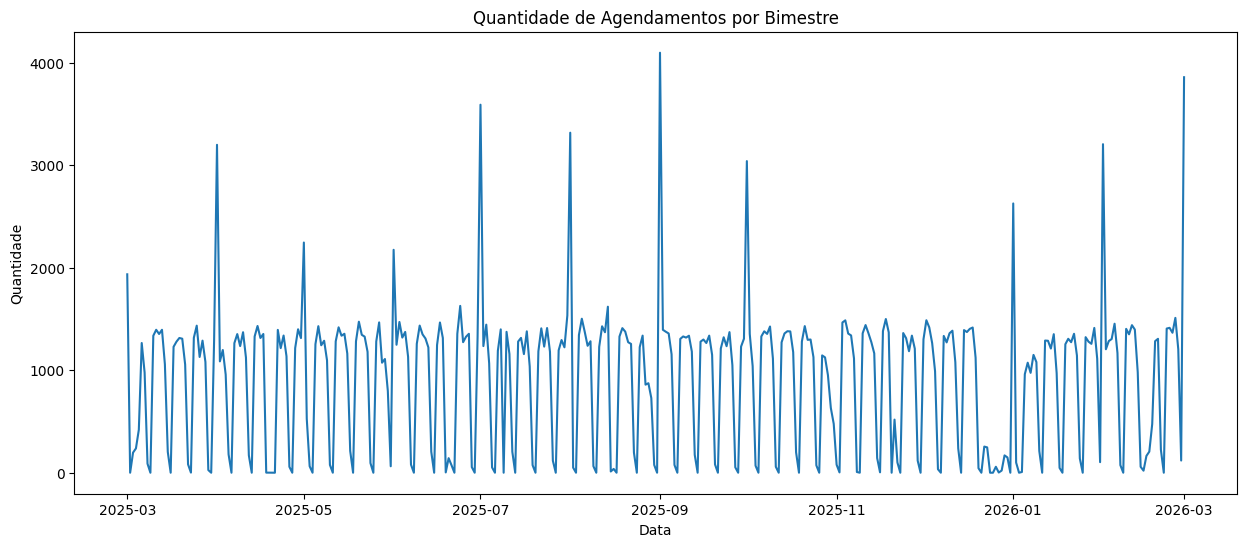

In [74]:
plt.figure(figsize=(15,6))

plt.plot(
    ag_por_dia.index,
    ag_por_dia.values
)

plt.title('Quantidade de Agendamentos por Bimestre')

plt.xlabel('Data')

plt.ylabel('Quantidade')

plt.show()

# Distribuição de Agendamentos por Hora

In [75]:
horarios = (
    agendamentos['hora']
    .value_counts()
    .sort_index()
)

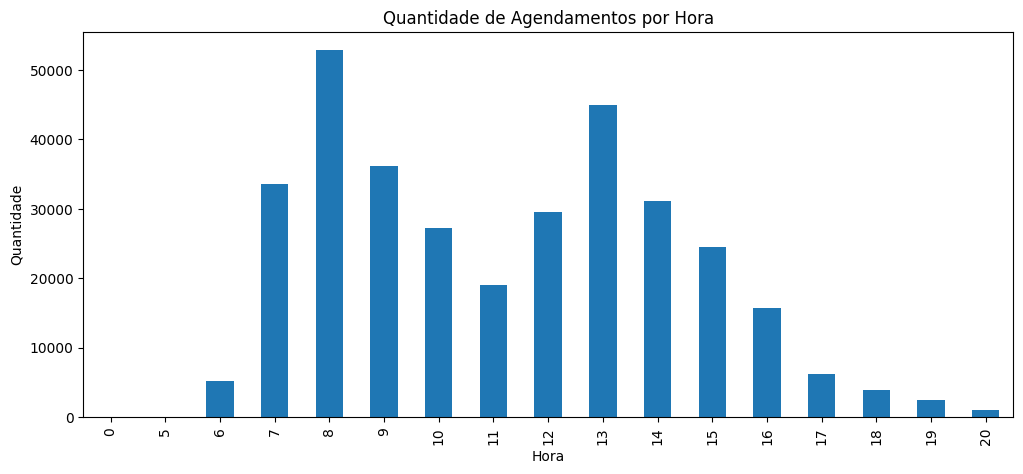

In [76]:
plt.figure(figsize=(12,5))

horarios.plot(kind='bar')

plt.title('Quantidade de Agendamentos por Hora')

plt.xlabel('Hora')

plt.ylabel('Quantidade')

plt.show()

# Horários Críticos

In [77]:
top_horarios = (
    agendamentos['hora']
    .value_counts()
    .sort_values(ascending=False)
    .head(10)
)

top_horarios

hora
8     52832
13    44967
9     36171
7     33506
14    31075
12    29474
10    27292
15    24539
11    19070
16    15692
Name: count, dtype: int64

# Distribuição por Faixa Horária

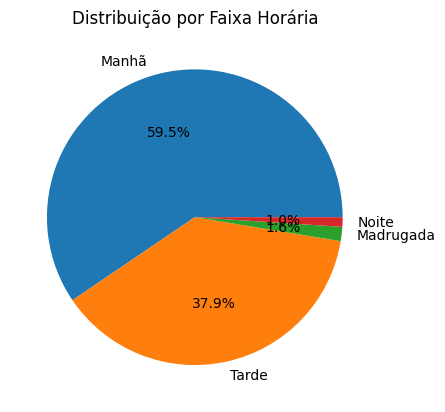

In [78]:
agendamentos['faixa_horaria'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Distribuição por Faixa Horária')

plt.ylabel('')

plt.show()

# Análise de Encaixes

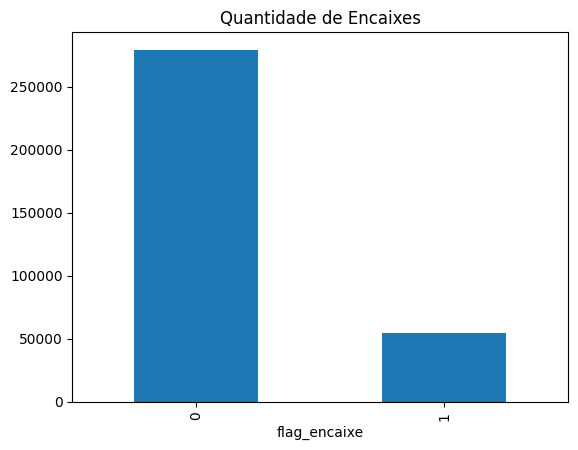

In [79]:
agendamentos['flag_encaixe'].value_counts().plot(
    kind='bar'
)

plt.title('Quantidade de Encaixes')

plt.show()

In [80]:
encaixe_hora = (
    agendamentos
    .groupby('hora')['flag_encaixe']
    .mean() * 100
)

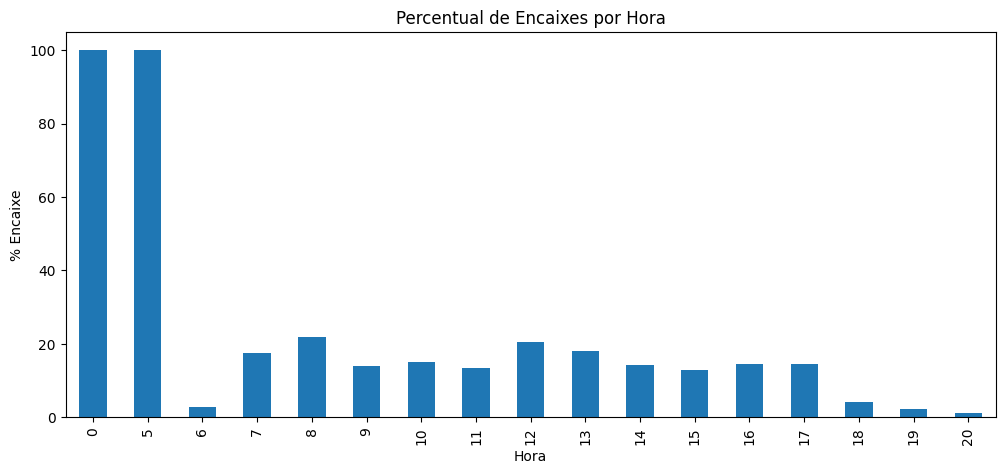

In [81]:
plt.figure(figsize=(12,5))

encaixe_hora.plot(kind='bar')

plt.title('Percentual de Encaixes por Hora')

plt.xlabel('Hora')

plt.ylabel('% Encaixe')

plt.show()

# Comparecimento e No-show

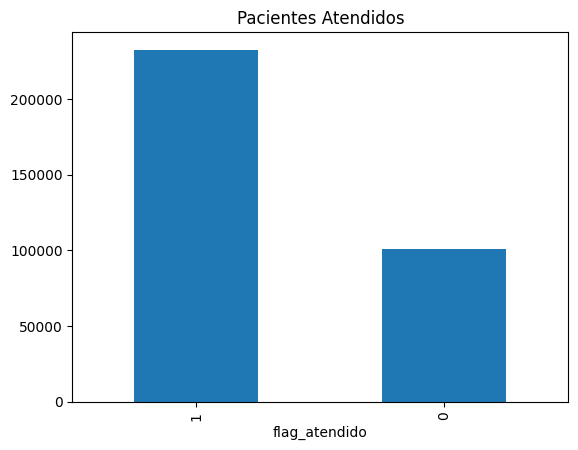

In [82]:
agendamentos['flag_atendido'].value_counts().plot(
    kind='bar'
)

plt.title('Pacientes Atendidos')

plt.show()

# Distribuição por Dia da Semana

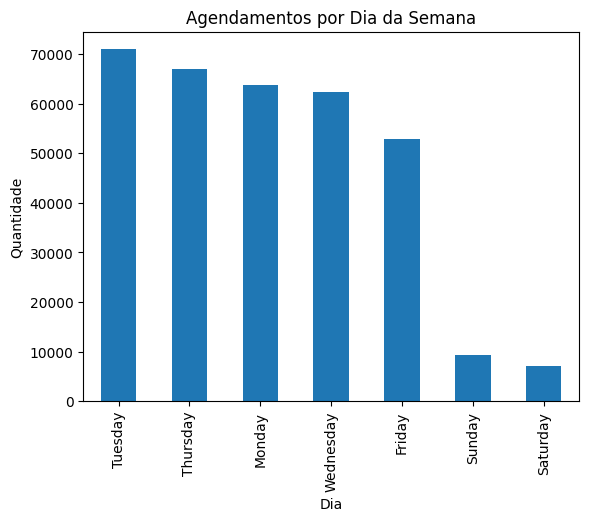

In [83]:
agendamentos['dia_semana'].value_counts().plot(
    kind='bar'
)

plt.title('Agendamentos por Dia da Semana')

plt.xlabel('Dia')

plt.ylabel('Quantidade')

plt.show()

# Heatmap Operacional

Objetivo:
- identificar gargalos
- identificar superlotação
- entender concentração operacional

In [84]:
pivot_horario = pd.crosstab(
    agendamentos['dia_semana'],
    agendamentos['hora']
)

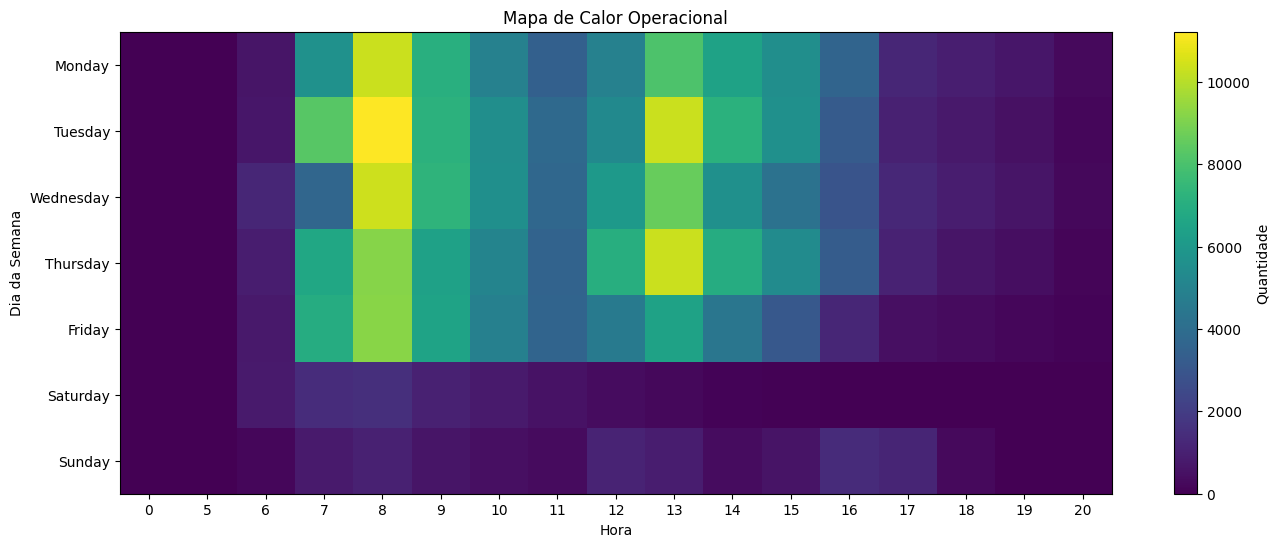

In [85]:
plt.figure(figsize=(16,6))

plt.imshow(
    pivot_horario,
    aspect='auto'
)

plt.colorbar(label='Quantidade')

plt.yticks(
    range(len(pivot_horario.index)),
    pivot_horario.index
)

plt.xticks(
    range(len(pivot_horario.columns)),
    pivot_horario.columns
)

plt.title('Mapa de Calor Operacional')

plt.xlabel('Hora')

plt.ylabel('Dia da Semana')

plt.show()

# Sazonalidade Mensal

In [86]:
ag_mes = (
    agendamentos['mes']
    .value_counts()
    .sort_index()
)

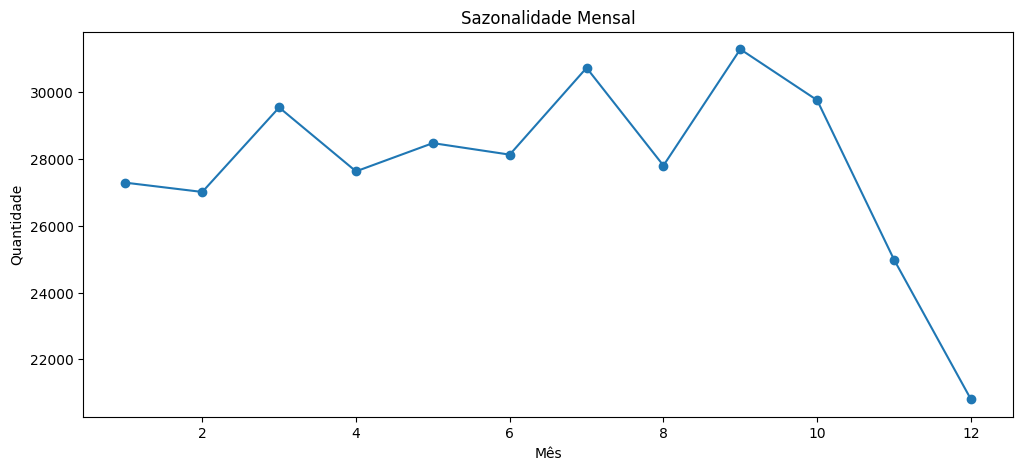

In [87]:
plt.figure(figsize=(12,5))

ag_mes.plot(
    kind='line',
    marker='o'
)

plt.title('Sazonalidade Mensal')

plt.xlabel('Mês')

plt.ylabel('Quantidade')

plt.show()

# Densidade Operacional

In [88]:
densidade = (
    agendamentos
    .groupby(['dia_semana', 'hora'])
    .size()
    .reset_index(name='quantidade')
)

In [89]:
densidade.sort_values(
    by='quantidade',
    ascending=False
).head(15)

,dia_semana,hora,quantidade
18,Tuesday,8,11216
34,Wednesday,8,10350
23,Tuesday,13,10334
55,Thursday,13,10320
3,Monday,8,10299
65,Friday,8,9242
50,Thursday,8,9157
39,Wednesday,13,8627
17,Tuesday,7,8293
8,Monday,13,8091


# Identificação de Dias Críticos

In [90]:
limite_superior = (
    ag_por_dia.mean() + 2 * ag_por_dia.std()
)

dias_criticos = ag_por_dia[
    ag_por_dia > limite_superior
]

dias_criticos.head(20)

dt_hr_agenda
2025-04-01    3198
2025-07-01    3589
2025-08-01    3316
2025-09-01    4096
2025-10-01    3039
2026-01-01    2626
2026-02-01    3204
2026-03-01    3857
dtype: int64

# Capacidade Operacional por Faixa Horária

In [91]:
agendamentos.groupby(
    'faixa_horaria'
).size()

faixa_horaria
Madrugada      5177
Manhã        198345
Tarde        126422
Noite          3471
dtype: int64

# Distribuição Médica

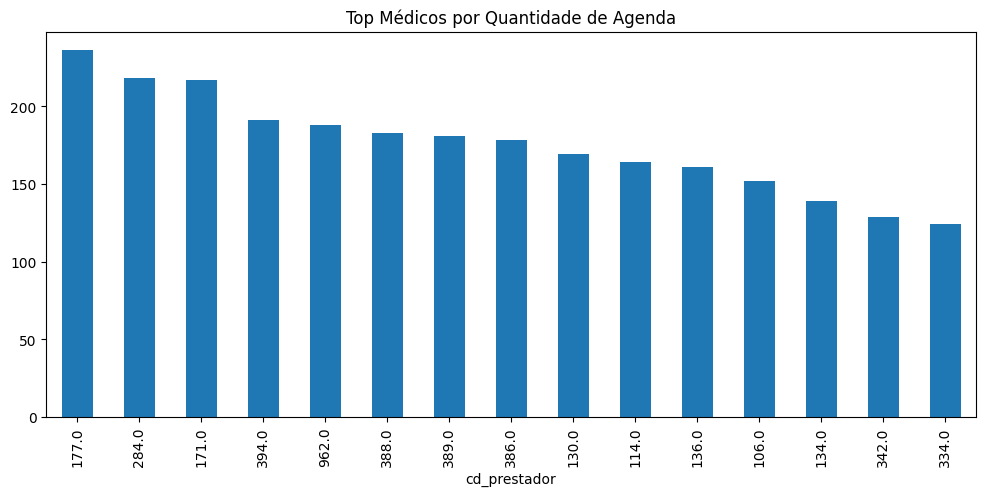

In [92]:
agenda['cd_prestador'].value_counts().head(15).plot(
    kind='bar',
    figsize=(12,5)
)

plt.title('Top Médicos por Quantidade de Agenda')

plt.show()

# Tempo Médio de Atendimento

In [93]:
agenda['qt_tempo_medio'].describe()

count    14557.000000
mean        19.919558
std         12.727714
min          1.000000
25%         10.000000
50%         20.000000
75%         20.000000
max         60.000000
Name: qt_tempo_medio, dtype: float64

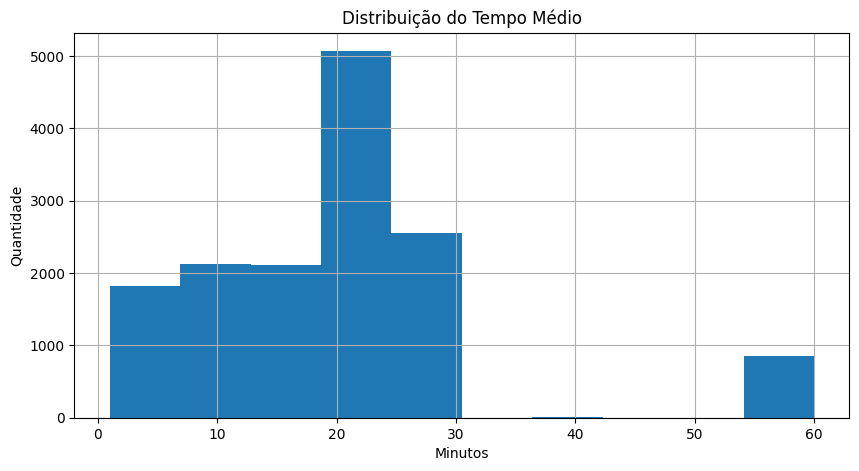

In [94]:
agenda['qt_tempo_medio'].hist(figsize=(10,5))

plt.title('Distribuição do Tempo Médio')
plt.xlabel('Minutos')
plt.ylabel('Quantidade')
plt.show()

# Procedimentos Mais Frequentes

In [95]:
procedimentos['ds_item_agendamento'] \
    .value_counts() \
    .head(20)

ds_item_agendamento
NAO USAR                                           29
NÃO USAR (INATIVO)                                 27
PROCESSAMENTO AUDITIVO                              3
REABILITACAO LABIRINTICA                            3
TESTE DE PROTESE AUDITIVA (AASI)                    3
MAPEAMENTO DE RETINA                                3
NÃO USAR                                            3
VISAO SUB NORMAL                                    2
TESTE DE TELLER                                     2
EXERCICIOS ORTOPTICOS                               2
TESTE DE SENSIBILIDADE DE CONTRASTE OU DE CORES     2
ELETROCARDIOGRAMA                                   2
AVALIACAO ENDOSCOPICA DA DEGLUTICAO (FEES)          2
AVALIACAO PRE IMPLANTE COCLEAR                      2
CURVA TENSIONAL DIARIA                              2
TONOMETRIA                                          2
GONIOSCOPIA                                         2
FUNDOSCOPIA                                         2
BIOPSIA 

# Possíveis Causas de Overbooking Identificadas

Com base na análise exploratória, os possíveis fatores associados ao overbooking incluem:

- concentração excessiva em horários específicos
- alta taxa de encaixes
- distribuição desigual da demanda
- picos operacionais em determinados dias
- excesso de carga em determinados médicos
- tentativa de compensação de no-show
- sazonalidade operacional
- má distribuição temporal das agendas

---

# Recomendações Estratégicas

## Curto Prazo
- limitar encaixes em horários críticos
- redistribuir agendas
- balancear carga médica
- criar alerta operacional para horários críticos

## Médio Prazo
- previsão de demanda
- modelo preditivo de no-show
- otimização de agenda médica

## Longo Prazo
- dashboard em tempo real
- sistema inteligente de capacidade operacional
- machine learning para previsão de superlotação